# Reducing LLM Token Cost and Response Time:

### A Granular Basic-to-Advanced Lecture for AI Engineers.

Reducing tokens frequently reduces both cost and latency, but the relationship is not perfectly linear. 
For a hosted API, the approximate request cost is:

```
Request cost = 
Uncached input tokens x input-token price
+
Cached input tokens x cached-token price
+ 
Visible output tokens x  output-token price
+
Reasoning tokens x applicable output-token price
+
Tool, search, storage,or infrastructure charges
```
For a self-hosted model, cost is better represented as:

```
Infrastructure cost per successful task =

GPU cost per hour
x
Total GPU-hours consumed
÷
Number of successful tasks
```

These two perspective are different.

With an API, you usually optimize the number and type of billed tokens.

With self-hosting, you optimize:
    * GPU memory;
    * GPU utilization;
    * Throughput;
    * Batching efficiency;
    * Queueing delay;
    * Electricity and infrastucture;
    * Successful requests per unit of hardware.

# 2. The anatomy of LLM response time:

End-to-end response time can be decomposed into:


```
Total latency =
Client network latency
+
API gateway latency
+ 
Queue waiting time
+
Prompt preprocessing
+
Prefill
+ 
Decode
+
Tool Execution
+
Validation
+ 
Response transmission
```

## 2.1 Prefill
During prefill, the model process the input prompt and constructs the attention key-value cache.

Prefil cost  grows primarily with:
    * Prompt length;
    * Model size;
    * Attention implementation;
    * Hardware;
    * Batch Composition.
Long system prompts, large retrieved contexts, long conversation histories, and verbose tool outputs mainly increase prefill work.

### 2.2 Decode:

During decode, the model generates output tokens autoregressively.
Conceptually:

```
Generate token 1
 ↓
Use tokens 1...n to generate token n+1
 ↓
Repeat
```

Decode time is strongly influenced by:
    * Number of generated tokens;
    * Model size;
    * Memory bandwidth;
    * Batching;
    * KV-cache size;
    * Speculating decoding;
    * Quantize;
    * Inference-engine efficiency.

### 2.3 Time to first token:

Time to first token, or TTFT, measures how long the user waits before receiving the beginning of the answer.

Approximately:

```
TTFT =
Network
+
Queue
+
Prompt Engineering
+
Prefill
+
First decode step
```

### 2.4 Time per output token:

Time per output token, or TPOT, measures the average time between generated tokens after generation starts.

### 2.5 End-to-end latency:

End-to-end latency measures the complete request:

```
Request submitted
        ↓
Entire final response received
```

### 2.6 Throughput:

Throughput measures total work completed over time.
```
Requests per second

Tokens per second

Successful tasks per GPU-hour
```

A system can have excellent throughput but poor latency for an individual user.

### 2.7 Goodput:
Goodput counts work that meets defined service objectives.

For example:

```
Successful requests
That satisfu both:
TTFT < 2 seconds
and 
TPOT < 50 milliseconds
```
This is often more useful than raw tokens per second because a system that processes many requests too slowly may have high throughput but poor user experience.

DistServe formalized the importance of treating prefil TTFT and decode TPOT as separate serving objectives because the phases have different computaional characteristics and can interfere with each other.

# 4. Four different optimization goals:

Before changing anything, define your primary goal.

* Goal A: Lower monetary cost:

Examples:
    * Reduce monthly API expenditure;
    * Reduce GPU requirements;
    * Process offline work more cheaply;
    * Reduce cost per successful task.

* Goal B: Lower actual latency:

Examples:
        * Stream partial output;
        * Show retrieval progress;
        * Return a quick preliminary anser;
        * Update the interface while processing countinues.

* Goal D: Increase throughput:
Examples:
        * Serves more concurrent users;
        * Process more batch jobs per GPU;
        * Improve GPU utilization;
        * Increase tokens generated per second.
    
A technique may improve one objective while learning another.

For example: 
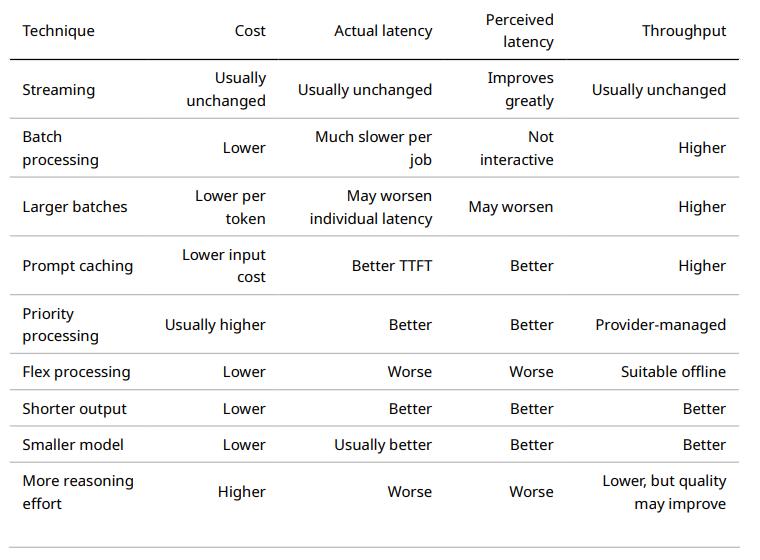 

# 4. The optimization hierarchy:
A disciplined engineer should optimize in roughly this order:

```
1. Measure the workload.
2. Eliminate unnecessary LLM calls.
3. Generate fewer output and reasoning tokens.
4. Send fewer input tokens.
5. Reuse previous computation.
6. Use the smallest model that meets quality requirements.
7. Reduce sequential workflow stages.
8. Select the appropriate provider processing tier.
9. Optimize the inference engine.
10. Apply experimental state-of-the-art methods.
```
The earlier techniques are usually:

    * Safer;
    * Easier;
    * Cheaper to implement;
    * More transferable across providers.
Do not begin with GPU kernel optimization while your application is sending 40,000 irrelevant tokens per request.

